# 07. Model Classification: Selection - PySpark

## 07.1. Importação das bibliotecas

### 07.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
from typing import Any

### 07.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from pyspark.sql import SparkSession, types as T
from pyspark.sql.functions import *
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

### 07.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pyspark as fn_stats_pyspark
import params.consts as consts

## 07.2. Visão geral dos dados

### 07.2.0. Iniciando a sessão Spark

In [4]:
spark = SparkSession.builder.appName('spark').getOrCreate()

### 07.2.1. Habilitando a exibição de todas as colunas e linhas

In [5]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 07.2.2. Armazenando o dataset em uma variável

In [6]:
df = spark.read \
    .format('parquet') \
    .load(consts.DATASET_CLUSTERED_PYSPARK)

### 07.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [7]:
(df.count(), len(df.columns))

(2205, 23)

### 07.2.4. Exibindo o dataset

In [8]:
df.show(5)

+----------+--------------+--------+-----------+---+--------+-------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
| Education|Marital_Status|Children|HasChildren|Age|AgeGroup| Income|Recency|Complain|Dt_Customer_Month|Dt_Customer_Quarter|Days_Since_Enrolled|Years_Since_Enrolled|NumDealsPurchases|NumWebVisitsMonth|NumTotalPurchases|MntRegularProds|MntGoldProds|MntTotal|AcceptedCmpTotal|HasAcceptedCmp|Response|Cluster|
+----------+--------------+--------+-----------+---+--------+-------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|       PhD|        Single|       1|          1| 46|   46-60|50616.0|     56|  

### 07.2.5. Visualizando os detalhes do dataset

In [9]:
df.printSchema()

root
 |-- Education: string (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- Children: integer (nullable = true)
 |-- HasChildren: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- AgeGroup: string (nullable = true)
 |-- Income: double (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Complain: integer (nullable = true)
 |-- Dt_Customer_Month: integer (nullable = true)
 |-- Dt_Customer_Quarter: integer (nullable = true)
 |-- Days_Since_Enrolled: integer (nullable = true)
 |-- Years_Since_Enrolled: long (nullable = true)
 |-- NumDealsPurchases: integer (nullable = true)
 |-- NumWebVisitsMonth: integer (nullable = true)
 |-- NumTotalPurchases: integer (nullable = true)
 |-- MntRegularProds: integer (nullable = true)
 |-- MntGoldProds: integer (nullable = true)
 |-- MntTotal: integer (nullable = true)
 |-- AcceptedCmpTotal: integer (nullable = true)
 |-- HasAcceptedCmp: integer (nullable = true)
 |-- Response: integer (nullable = true)
 |-

### 07.2.6. Visualizando as estatísticas das colunas numéricas

In [10]:
fn_stats_pyspark.summary(df).show(truncate = False)

+-------+---------+--------------+--------+-----------+------+--------+--------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|summary|Education|Marital_Status|Children|HasChildren|Age   |AgeGroup|Income  |Recency|Complain|Dt_Customer_Month|Dt_Customer_Quarter|Days_Since_Enrolled|Years_Since_Enrolled|NumDealsPurchases|NumWebVisitsMonth|NumTotalPurchases|MntRegularProds|MntGoldProds|MntTotal|AcceptedCmpTotal|HasAcceptedCmp|Response|Cluster|
+-------+---------+--------------+--------+-----------+------+--------+--------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|count  |2205     |2205          |2205.0  |220

### 07.2.7. Visualizando as estatísticas da colunas categóricas

In [11]:
categorical_columns = [field.name for field in df.schema.fields if isinstance(field.dataType, T.StringType)]

df.describe(categorical_columns).show()

+-------+---------+--------------+--------+
|summary|Education|Marital_Status|AgeGroup|
+-------+---------+--------------+--------+
|  count|     2205|          2205|    2205|
|   mean|     NULL|          NULL|    NULL|
| stddev|     NULL|          NULL|    NULL|
|    min| 2n Cycle|       Partner|   18-30|
|    max|      PhD|        Single|     61+|
+-------+---------+--------------+--------+



### 07.2.8. Verificando os valores nulos das colunas

In [12]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---------+--------------+--------+-----------+---+--------+------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|Education|Marital_Status|Children|HasChildren|Age|AgeGroup|Income|Recency|Complain|Dt_Customer_Month|Dt_Customer_Quarter|Days_Since_Enrolled|Years_Since_Enrolled|NumDealsPurchases|NumWebVisitsMonth|NumTotalPurchases|MntRegularProds|MntGoldProds|MntTotal|AcceptedCmpTotal|HasAcceptedCmp|Response|Cluster|
+---------+--------------+--------+-----------+---+--------+------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|        0|             0|       0|          0|  0|       0|     0|      0|       0| 

### 07.2.9. Verificando os valores distintos das colunas

In [13]:
df.select([count_distinct(c).alias(c) for c in df.columns]).show()

+---------+--------------+--------+-----------+---+--------+------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|Education|Marital_Status|Children|HasChildren|Age|AgeGroup|Income|Recency|Complain|Dt_Customer_Month|Dt_Customer_Quarter|Days_Since_Enrolled|Years_Since_Enrolled|NumDealsPurchases|NumWebVisitsMonth|NumTotalPurchases|MntRegularProds|MntGoldProds|MntTotal|AcceptedCmpTotal|HasAcceptedCmp|Response|Cluster|
+---------+--------------+--------+-----------+---+--------+------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+--------+-------+
|        5|             2|       4|          2| 56|       4|  1963|    100|       2| 

### 07.2.10. Verificando os registos totalmente duplicados

In [14]:
df.count() - df.dropDuplicates().count()

185

### 07.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [15]:
num_cols = __builtins__.sum(isinstance(df.schema[c].dataType, T.NumericType) for c in df.columns)

categ_cols = __builtins__.sum(isinstance(df.schema[c].dataType, T.StringType) for c in df.columns)

date_cols = __builtins__.sum(isinstance(df.schema[c].dataType, (T.DateType, T.TimestampType)) for c in df.columns)

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 20
- Categoric Columns: 3
- Date Columns: 0


## 07.3. Treinamento dos modelos

### 07.3.0. Convertendo o df PySpark para Pandas

In [16]:
df_pd = df.toPandas()

### 07.3.1. Definindo os valores de X e y

In [17]:
X = df.drop('Response')

X_pd = X.toPandas()

X.show(5)

+----------+--------------+--------+-----------+---+--------+-------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+-------+
| Education|Marital_Status|Children|HasChildren|Age|AgeGroup| Income|Recency|Complain|Dt_Customer_Month|Dt_Customer_Quarter|Days_Since_Enrolled|Years_Since_Enrolled|NumDealsPurchases|NumWebVisitsMonth|NumTotalPurchases|MntRegularProds|MntGoldProds|MntTotal|AcceptedCmpTotal|HasAcceptedCmp|Cluster|
+----------+--------------+--------+-----------+---+--------+-------+-------+--------+-----------------+-------------------+-------------------+--------------------+-----------------+-----------------+-----------------+---------------+------------+--------+----------------+--------------+-------+
|       PhD|        Single|       1|          1| 46|   46-60|50616.0|     56|       0|                4|  

In [18]:
y = df.select('Response')

y_pd = y.toPandas()['Response']

y.show(5)

+--------+
|Response|
+--------+
|       0|
|       0|
|       1|
|       0|
|       0|
+--------+
only showing top 5 rows


### 07.3.2. Dividindo os valores de X e y em dados de treino, validação e teste

In [19]:
print(df_pd.shape)

print(X_pd.shape, y_pd.shape)

X_pd_train_val, X_pd_test, y_pd_train_val, y_pd_test = train_test_split(X_pd, y_pd, test_size = 0.2, random_state = consts.RANDOM_STATE, stratify = y_pd)

print(X_pd_train_val.shape, X_pd_test.shape, y_pd_train_val.shape, y_pd_test.shape)

(2205, 23)
(2205, 22) (2205,)
(1764, 22) (441, 22) (1764,) (441,)


### 07.3.3. Listando as colunas numéricas e categóricas

In [20]:
numerical_features = X_pd_train_val.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- Children
- HasChildren
- Age
- Income
- Recency
- Complain
- Dt_Customer_Month
- Dt_Customer_Quarter
- Days_Since_Enrolled
- Years_Since_Enrolled
- NumDealsPurchases
- NumWebVisitsMonth
- NumTotalPurchases
- MntRegularProds
- MntGoldProds
- MntTotal
- AcceptedCmpTotal
- HasAcceptedCmp
- Cluster


In [21]:
categorical_features = X_pd_train_val.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- Education
- Marital_Status
- AgeGroup


### 07.3.4. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


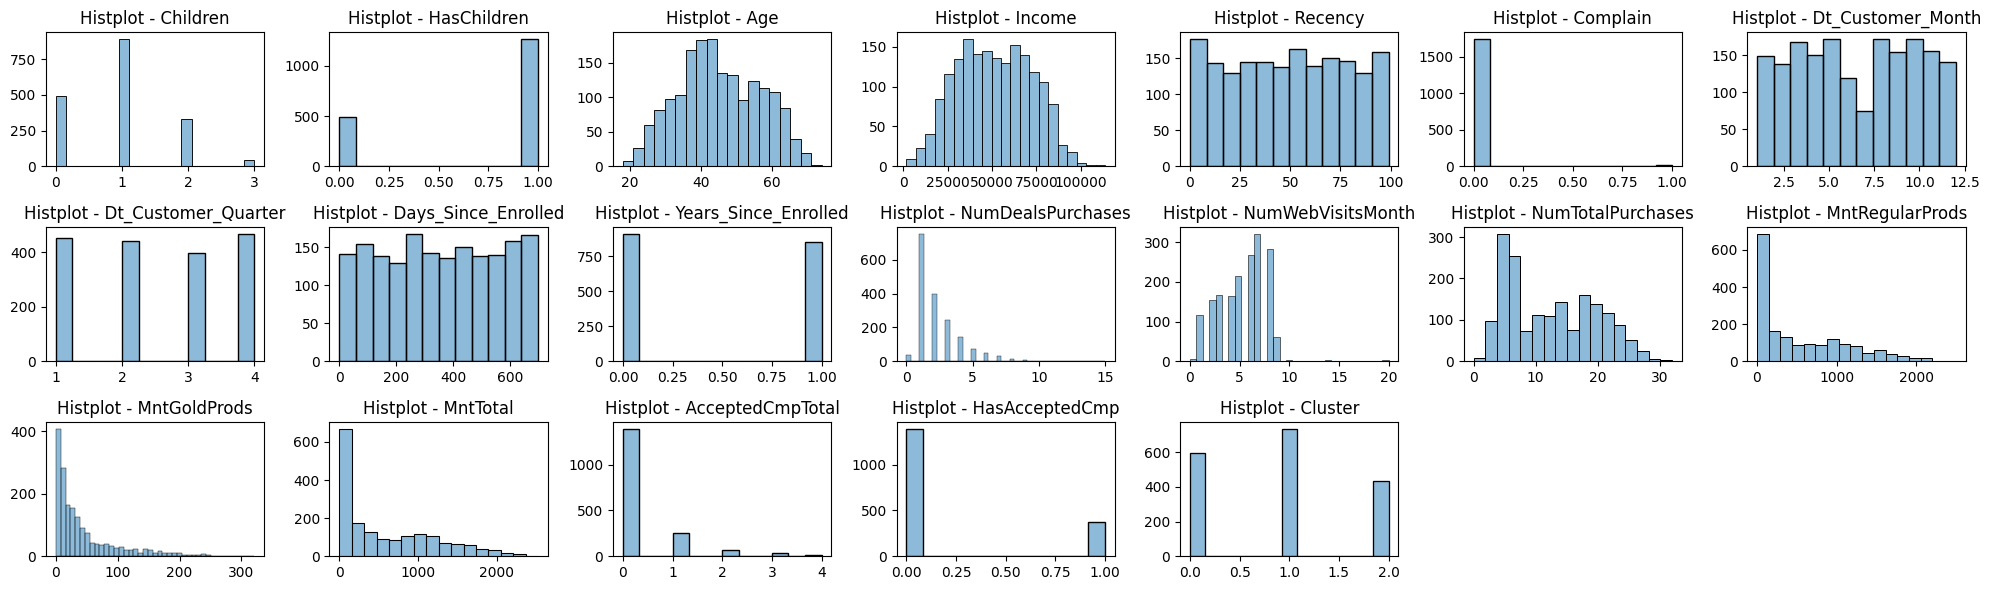

In [22]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X_pd_train_val, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pyspark/nb07_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 07.3.5. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Standard Scaler:** Indicado para colunas com distribuição semelhante à normal.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [23]:
one_hot_encoder_columns = [
    'Education',
    'Marital_Status',
    'AgeGroup',
    'Children',
    'HasChildren',
    'Complain',
    'Years_Since_Enrolled',
    'AcceptedCmpTotal',
    'HasAcceptedCmp',
    'Cluster',
]

standard_scaler_columns = [
    'Income',
    'Age',
]

power_transformer_columns = [
   'NumDealsPurchases',
   'NumWebVisitsMonth',
   'NumTotalPurchases',
   'MntRegularProds',
   'MntGoldProds',
   'MntTotal',
]

min_max_scaler_columns = [
    'Recency',
    'Dt_Customer_Month',
    'Dt_Customer_Quarter',
    'Days_Since_Enrolled',
]

### 07.3.6. Criando um pipeline dos pré processamentos que serão aplicados nas colunas

In [24]:
pipeline_pre_processing = ColumnTransformer([

    ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

    ('standard_scaler', StandardScaler(), standard_scaler_columns),

    ('power_transformer', PowerTransformer(), power_transformer_columns),

    ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)

])

### 07.3.7. Criando uma função com o pipeline para treinar os modelos

In [25]:
def pipeline_scikit_learn(X: pd.DataFrame, y: pd.Series, model: BaseEstimator) -> dict[str, Any]:
    """
    Função que executa todo o fluxo de machine learning: pré-processamento, seleção de features,
    balanceamento de classes, treinamento do modelo e validação cruzada.

    Args:
        X (pd.DataFrame): Valores de X.
        y (pd.Series): Variável alvo.
        model (BaseEstimator): Modelo de machine learning.

    Returns:
        dict: Dicionário com as métricas dos treinamentos.
    """

    pipeline = Pipeline([

        ('pre_processing', pipeline_pre_processing),

        ('feature_selection', SelectKBest(score_func = f_classif, k = 10)),

        ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),

        ('model', model)

    ])

    scores = cross_validate(
        
        pipeline,

        X,

        y,

        cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = consts.RANDOM_STATE),

        scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'],

        n_jobs = -2

    )

    return scores

### 07.3.8. Treinando os modelos e armazenando suas métricas

In [26]:
scores = {

    'DummyClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, DummyClassifier(strategy = 'stratified', random_state = consts.RANDOM_STATE)),

    'LogisticRegression': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, LogisticRegression(random_state = consts.RANDOM_STATE)),

    'DecisionTreeClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, DecisionTreeClassifier(random_state = consts.RANDOM_STATE)),

    'KNNClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, KNeighborsClassifier(n_neighbors = 5)),

    'SVC': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, SVC(random_state = consts.RANDOM_STATE)),

    'ExtraTreesClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, ExtraTreesClassifier(random_state = consts.RANDOM_STATE)),

    'RandomForestClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, RandomForestClassifier(random_state = consts.RANDOM_STATE)),

    'GradientBoostingClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, GradientBoostingClassifier(random_state = consts.RANDOM_STATE)),

    'AdaBoostClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, AdaBoostClassifier(random_state = consts.RANDOM_STATE)),

    'XGBClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, XGBClassifier(random_state = consts.RANDOM_STATE)),

    'MLPClassifier': pipeline_scikit_learn(X_pd_train_val, y_pd_train_val, MLPClassifier(random_state = consts.RANDOM_STATE)),

}

### 07.3.9. Comentando as ações realizadas para evitar overfitting e underfitting nos modelos

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Balanceamento de Classes:** No aspecto de Balanceamento de Classes, como o dataset do projeto é desbalanceado, foi aplicado a técnica de Random Under Sampling (RUS) para se equiparar os valores da classe target ("Response"), onde se reduz a quantidade de valores da classe majoritária até que fique igual aos valores da classe minoritária.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o Stratified K-Fold, por ser um dataset desbalanceado, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.

## 07.4. Seleção do modelo

### 07.4.1. Criando um dataset com as métricas dos treinamentos dos modelos

In [27]:
for k, v in scores.items():

    scores[k]['Time'] = scores[k]['fit_time'] + scores[k]['score_time']

df_models_metrics = pd.DataFrame(scores).T.reset_index().rename(columns = {'index': 'Model'})

df_models_metrics = df_models_metrics.explode(df_models_metrics.columns[1:].to_list()).reset_index(drop = True)

df_models_metrics = df_models_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_models_metrics = df_models_metrics.drop(columns = ['fit_time', 'score_time'])

df_models_metrics = df_models_metrics.rename(columns = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall', 'roc_auc': 'ROC AUC', 'average_precision': 'Average Precision'})

df_models_metrics.to_csv(consts.DATASET_MODELS_METRICS_PYSPARK, index = False)

df_models_metrics

,Model,Accuracy,Precision,Recall,ROC AUC,Average Precision,Time
0,DummyClassifier,0.484419,0.122807,0.396226,0.448113,0.139311,0.095631
1,DummyClassifier,0.507082,0.146199,0.471698,0.492516,0.148282,0.093605
2,DummyClassifier,0.490085,0.128655,0.415094,0.459214,0.141223,0.075984
3,DummyClassifier,0.509915,0.152047,0.481481,0.498266,0.152528,0.103205
4,DummyClassifier,0.522727,0.163743,0.528302,0.525021,0.157528,0.069318
5,LogisticRegression,0.830028,0.450704,0.603774,0.786824,0.481105,0.099677
6,LogisticRegression,0.804533,0.413043,0.716981,0.837925,0.600773,0.100021
7,LogisticRegression,0.764873,0.366071,0.773585,0.854717,0.626478,0.075227
8,LogisticRegression,0.66289,0.235772,0.537037,0.725474,0.355035,0.111907
9,LogisticRegression,0.815341,0.411765,0.528302,0.695431,0.474228,0.080898


### 07.4.2. Criando diagramas de caixa para comparar as métricas dos modelos

- Gráfico: Diagrama de Caixa.


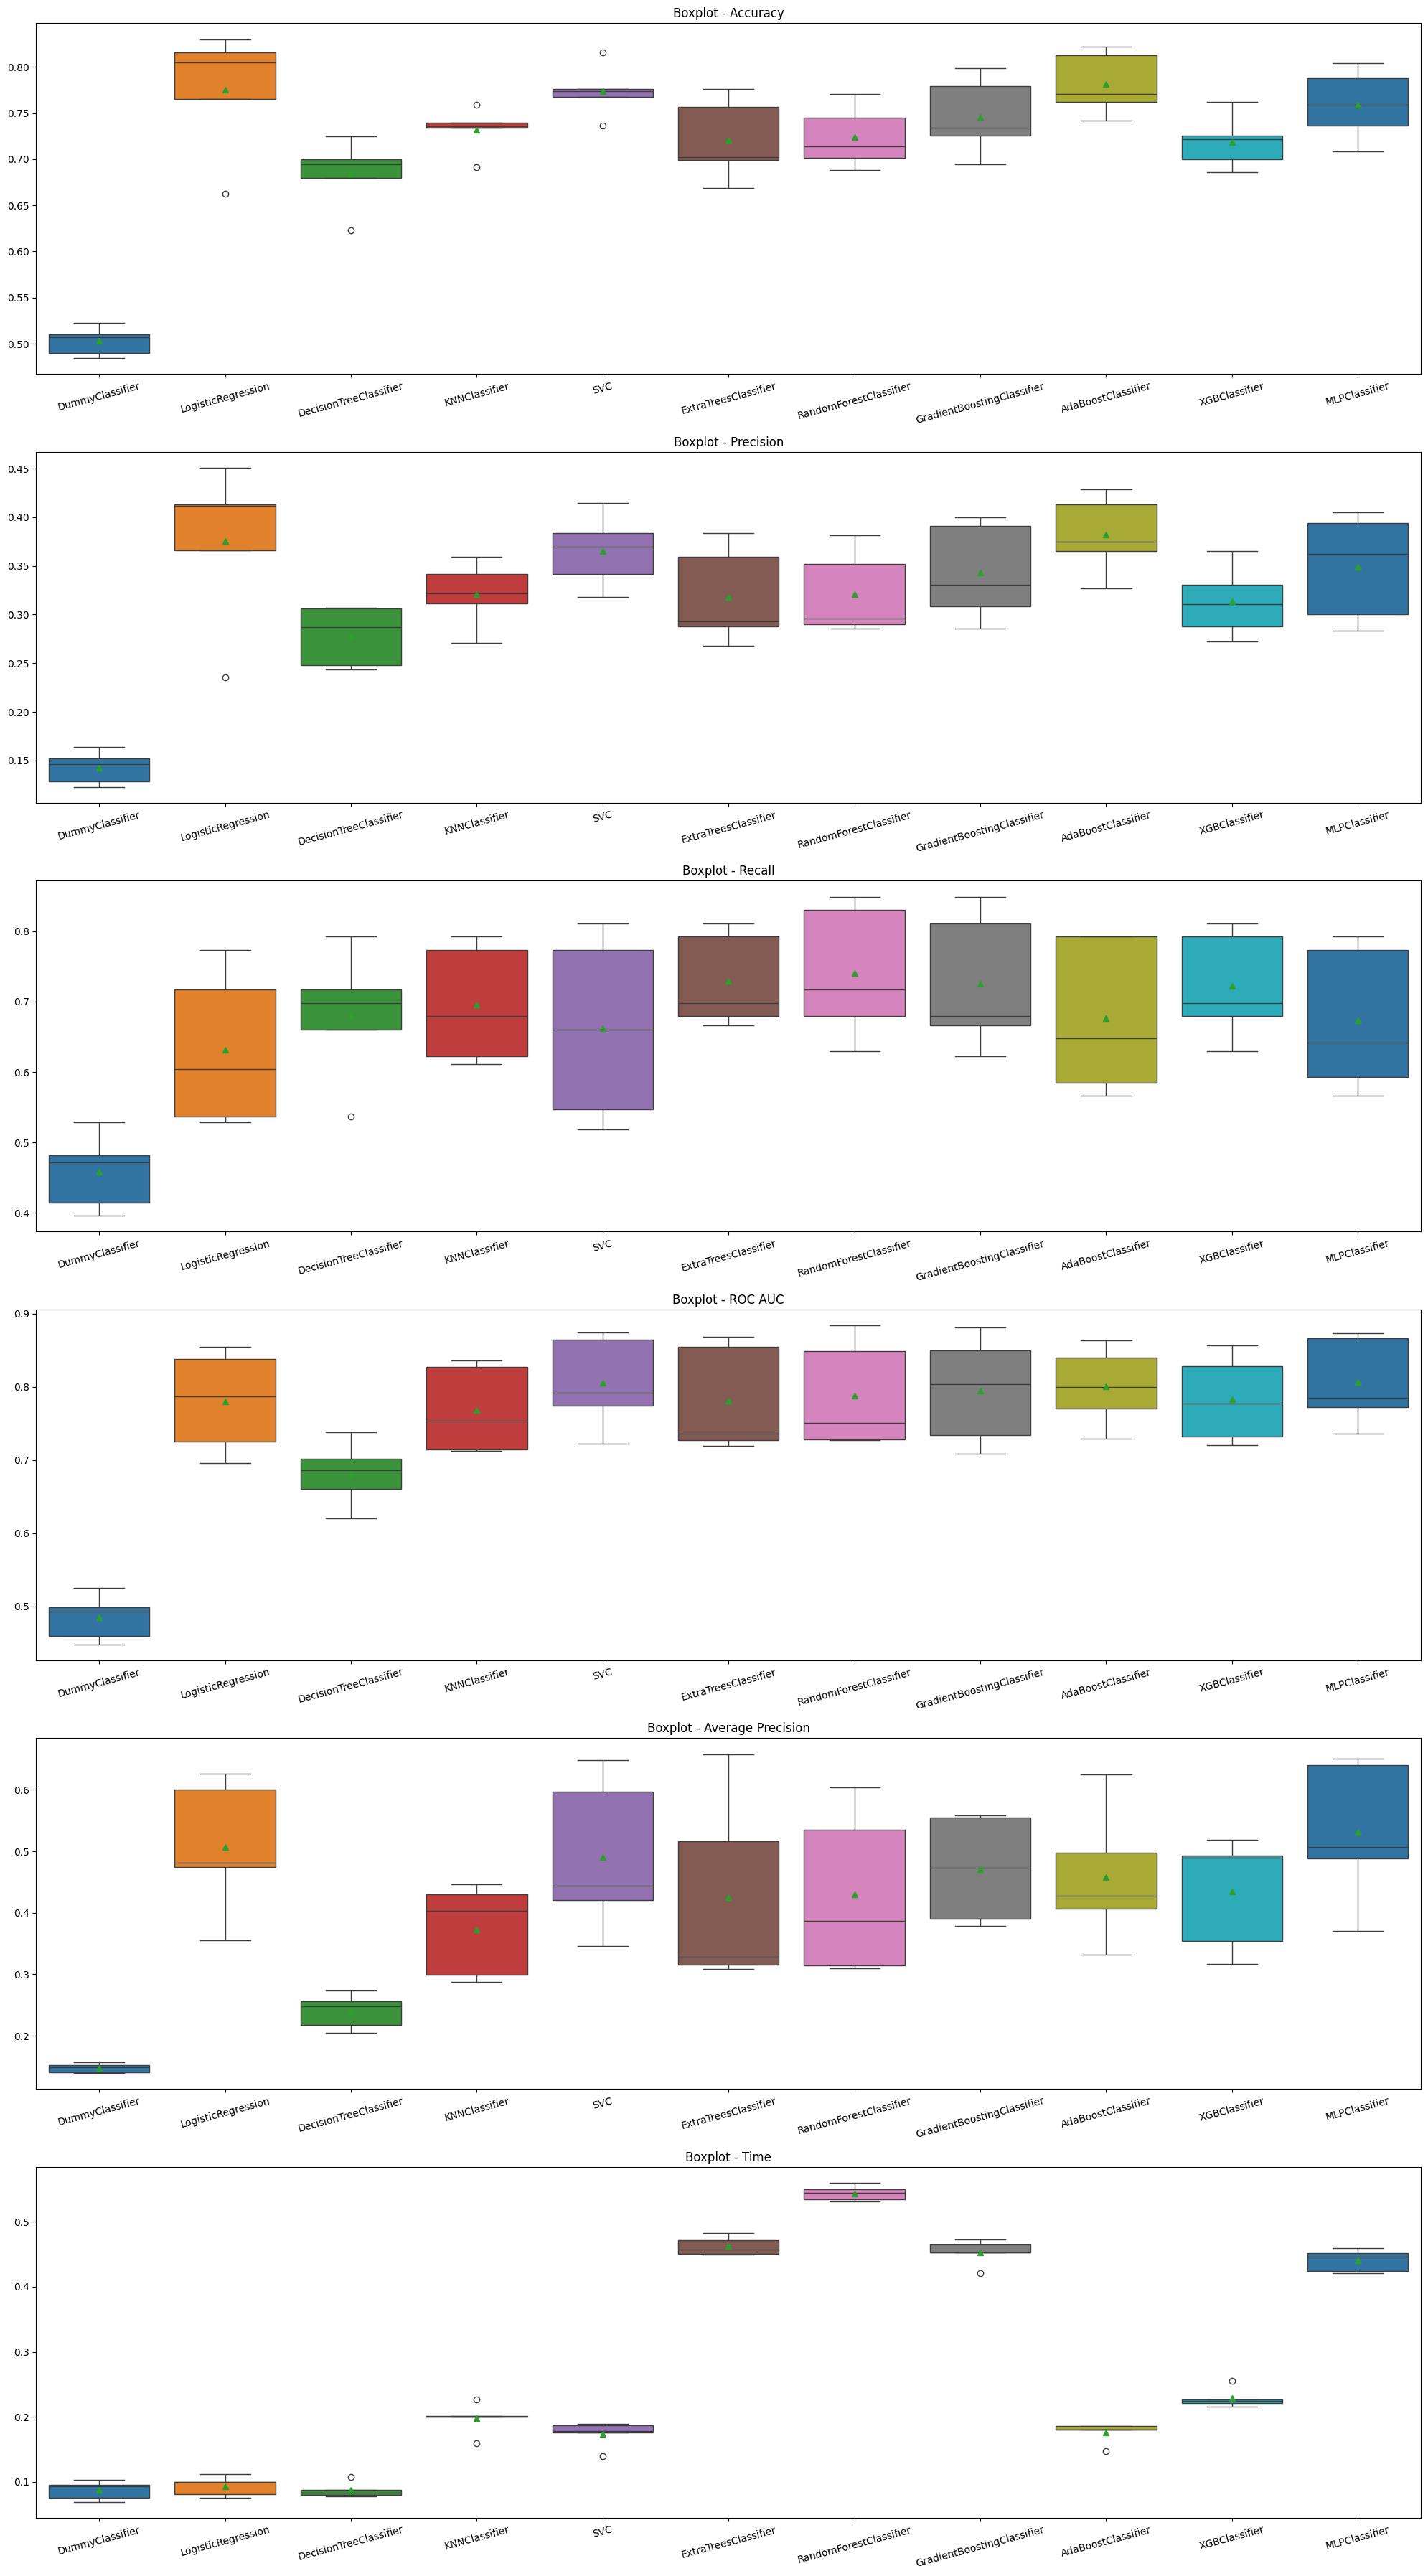

In [28]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_models_metrics, df_models_metrics.columns[1:].to_list(), 'Model', 'Model', num_cols = 1, height_figsize = 6, labelxrotation = 15)

plt.savefig(f'../images/outputs/charts/pyspark/nb07_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 07.4.3. Comparando a performance das métricas dos modelos e definindo o modelo selecionado

| Posição | Accuracy | Precision | Recall | ROC AUC | Average Precision | Time |
| :---: | :--- | :--- | :--- | :--- | :--- | :--- |
|Referência|Quanto maior melhor|Quanto maior melhor|Quanto maior melhor| Quanto maior melhor|Quanto maior melhor|Quanto menor melhor|
| **1º** | AdaBoostClassifier | AdaBoostClassifier | GradientBoostingClassifier | MLPClassifier | MLPClassifier | DecisionTreeClassifier |
| **2º** | GradientBoostingClassifier | GradientBoostingClassifier | ExtraTreesClassifier | SVC | LogisticRegression | LogisticRegression |
| **3º** | **LogisticRegression** | SVC | XGBClassifier | **LogisticRegression** | SVC | KNNClassifier |
| **4º** | MLPClassifier | MLPClassifier | MLPClassifier | RandomForestClassifier | ExtraTreesClassifier | DummyClassifier |
| **5º** | SVC | **LogisticRegression** | SVC | AdaBoostClassifier | AdaBoostClassifier | SVC |
| **6º** | ExtraTreesClassifier | RandomForestClassifier | KNNClassifier | GradientBoostingClassifier | RandomForestClassifier | ExtraTreesClassifier |
| **7º** | XGBClassifier | ExtraTreesClassifier | RandomForestClassifier | ExtraTreesClassifier | GradientBoostingClassifier | RandomForestClassifier |
| **8º** | RandomForestClassifier | XGBClassifier | AdaBoostClassifier | XGBClassifier | XGBClassifier | GradientBoostingClassifier |
| **9º** | KNNClassifier | KNNClassifier | **LogisticRegression** | KNNClassifier | KNNClassifier | AdaBoostClassifier |
| **10º** | DecisionTreeClassifier | DecisionTreeClassifier | DecisionTreeClassifier | DecisionTreeClassifier | DecisionTreeClassifier | XGBClassifier |
| **11º** | DummyClassifier | DummyClassifier | DummyClassifier | DummyClassifier | DummyClassifier | MLPClassifier |

- Modelo Selecionado: **LogisticRegression**